In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 75.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=35da1c4f2173d06acddb1d1fb50fc81c5654f380a9b33388d0983577d3e2009e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


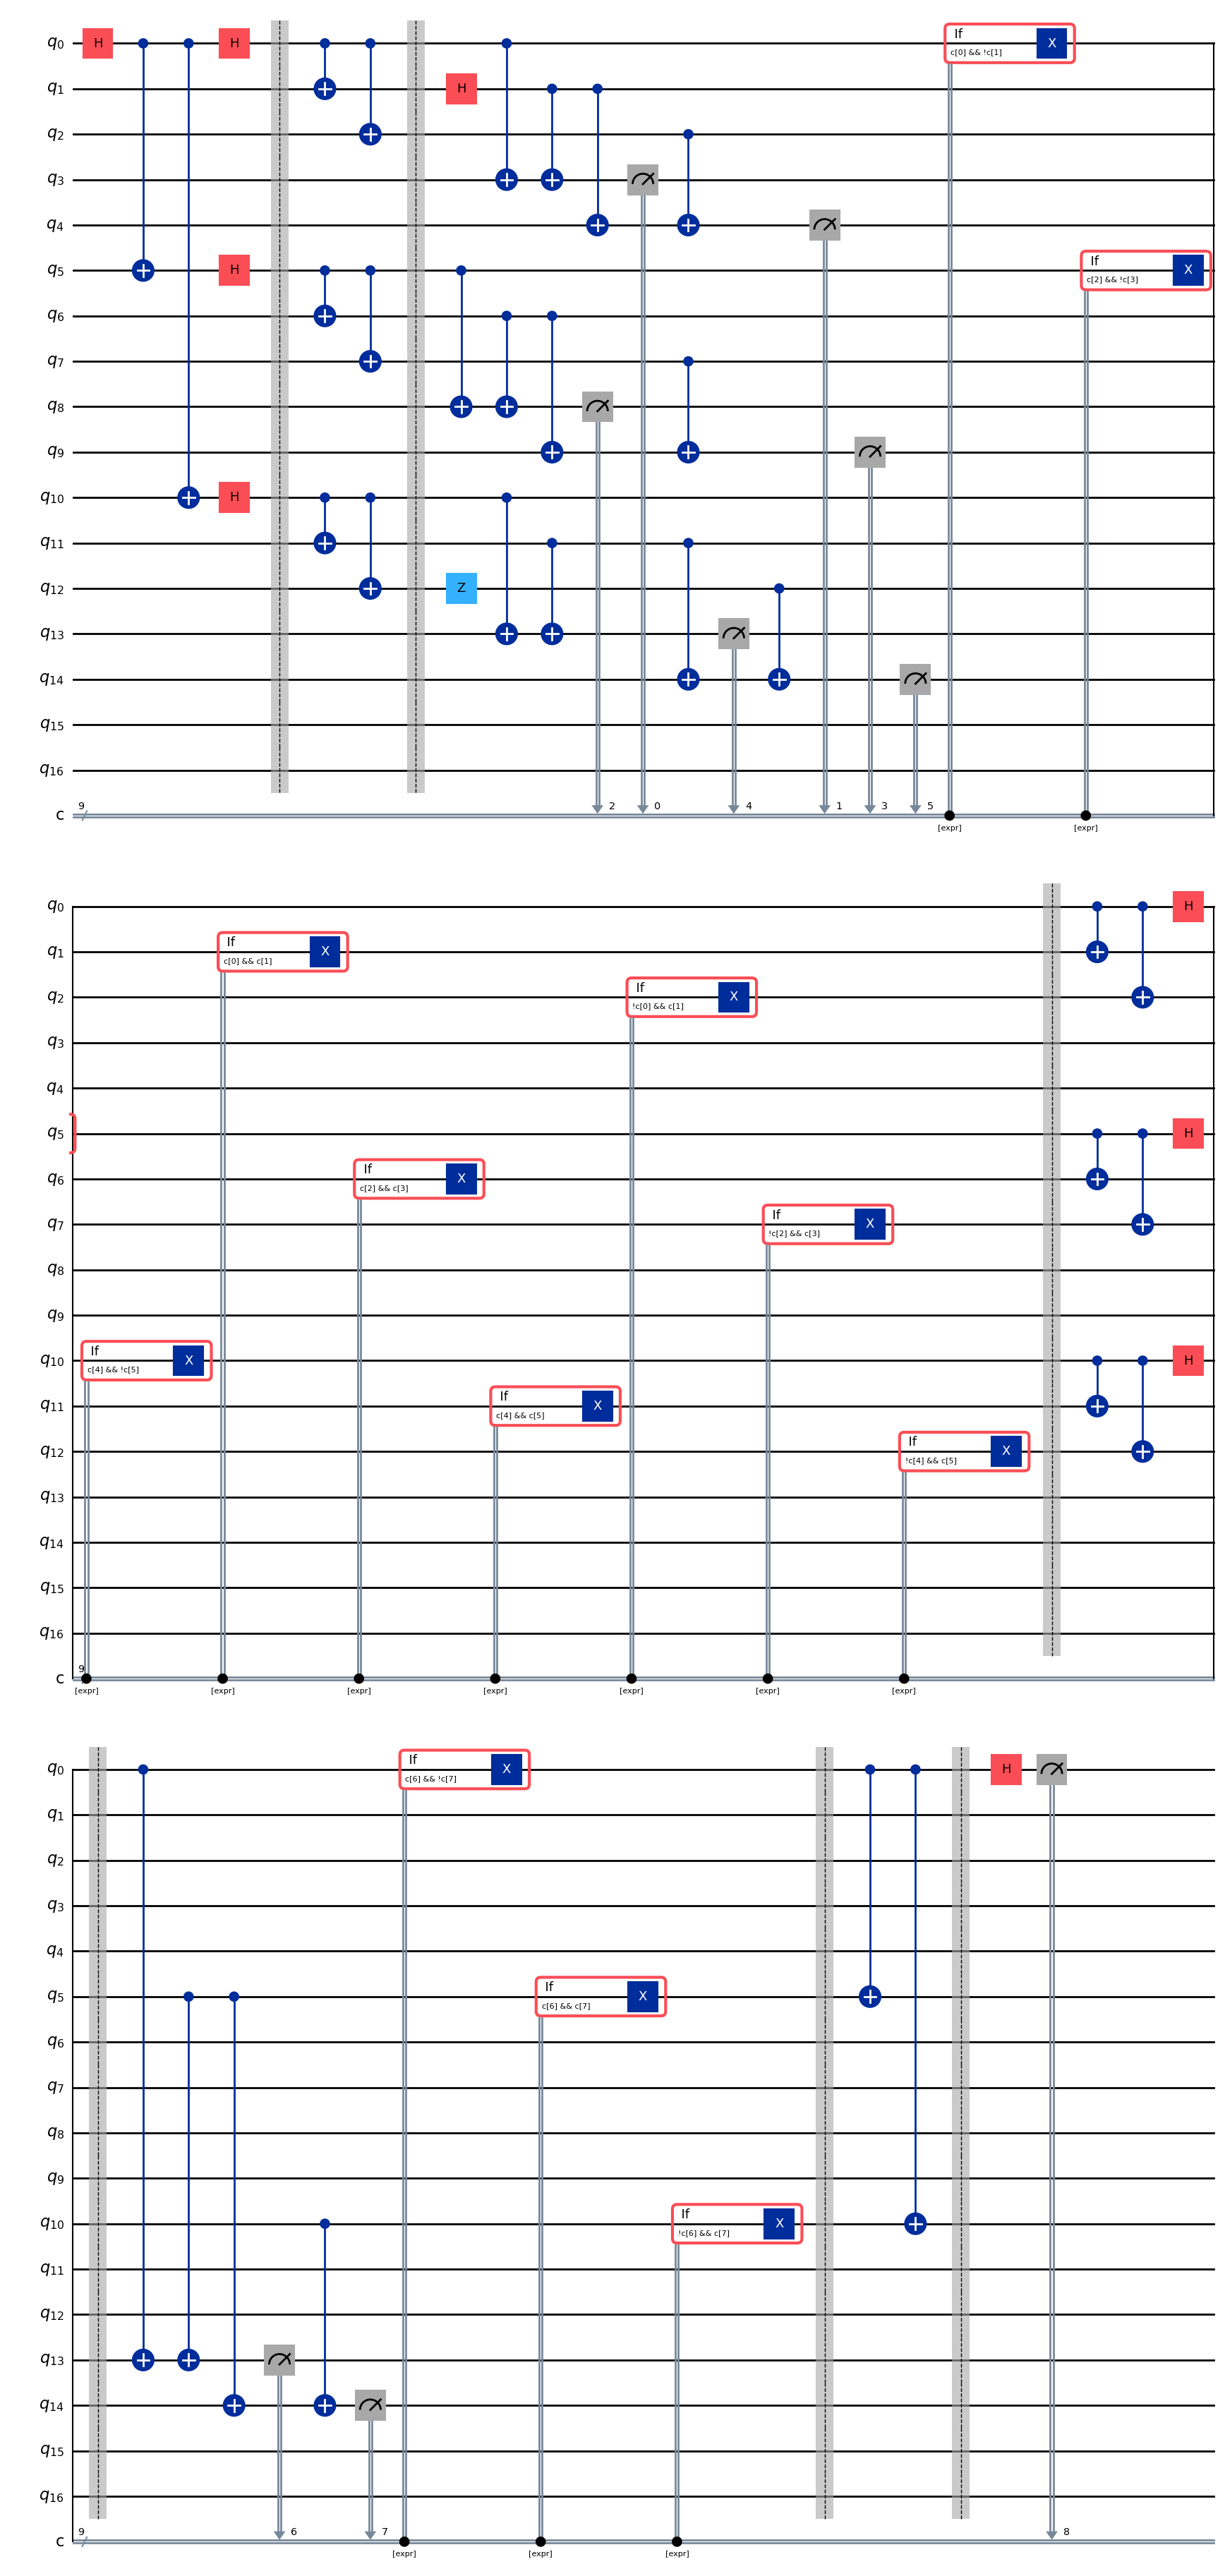

In [2]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor Code Implementation

# This code implements the Shor nine-qubit error correction code, which is designed to correct
# both bit-flip and phase-flip errors. The code encodes a single logical qubit into nine physical qubits.
# It works by combining three instances of the three-qubit bit-flip code, with an outer layer
# that corrects phase-flip errors.
#
# The overall structure involves:
# 1. Initializing the logical qubit in a superposition state.
# 2. Encoding the qubit for phase-flip error correction (outer code).
# 3. Encoding each of the three resulting qubits for bit-flip error correction (inner code).
# 4. Applying simulated errors.
# 5. Performing bit-flip error syndrome measurements and corrections for each inner code block.
# 6. Undoing the bit-flip encoding and applying Hadamard gates to prepare for phase-flip correction.
# 7. Performing phase-flip error syndrome measurements and corrections.
# 8. Undoing the phase-flip encoding.
# 9. Measuring the final state of the logical qubit to check for successful error correction.
#
# You can experiment with different types of errors (bit-flip, phase-flip, or other unitary operations like H).
# The simulation and measurement code in the next cell will need to be adapted for the 17 qubits used here.

# Initialize a quantum circuit with 17 qubits and 9 classical bits.
# The 17 qubits are used as follows:
# - Qubits 0, 5, 10: The primary qubits for the phase-flip code, each encoded by a bit-flip code.
# - Qubits 1, 2: Ancilla qubits for the bit-flip code associated with qubit 0.
# - Qubits 6, 7: Ancilla qubits for the bit-flip code associated with qubit 5.
# - Qubits 11, 12: Ancilla qubits for the bit-flip code associated with qubit 10.
# - Qubits 3, 4: Syndrome measurement ancilla qubits for the bit-flip code associated with qubits 0,1,2.
# - Qubits 8, 9: Syndrome measurement ancilla qubits for the bit-flip code associated with qubits 5,6,7.
# - Qubits 13, 14: Syndrome measurement ancilla qubits for the bit-flip code associated with qubits 10,11,12 and also for the phase-flip code.
# The 9 classical bits are used to store the measurement outcomes for error syndromes and the final logical qubit state.
shor = QuantumCircuit(17,9)

# Prepare the initial state of the logical qubit (qubit 0).
# Applying a Hadamard gate puts qubit 0 into the |+> state, which is a superposition
# of |0> and |1>. This state is sensitive to phase errors.
# The goal is to measure this qubit at the end in the diagonal basis (after another H gate)
# and expect a consistent result of '0' if error correction is successful.
shor.h(0)

# Phase-flip Encoding (Outer Code)
# This section encodes the initial state to protect against phase-flip errors.
# It creates three copies of the |+> state on qubits 0, 5, and 10, and then
# applies Hadamard gates to all three, effectively creating a superposition
# of |000> + |111> in the computational basis if the initial state was |+>.
# This forms the basis for the three-qubit phase-flip code.
shor.cx(0,5)  # CNOT from qubit 0 to qubit 5
shor.cx(0,10) # CNOT from qubit 0 to qubit 10
shor.h(0)     # Hadamard on qubit 0
shor.h(5)     # Hadamard on qubit 5
shor.h(10)    # Hadamard on qubit 10

shor.barrier() # Separator for visualization and logical grouping

# Bit-flip Encoding (Inner Code)
# Each of the three qubits (0, 5, 10) from the phase-flip encoding is now further encoded
# using a three-qubit bit-flip code. This means each logical qubit is now represented
# by three physical qubits, making a total of 9 physical qubits for the logical qubit.

# First qubit 0 and its ancillas 1, 2
# Encodes qubit 0 into qubits 0, 1, 2 using CNOT gates. The state |psi> -> |psi>|psi>|psi>
shor.cx(0,1)
shor.cx(0,2)

# Then qubit 5 and its ancillas 6, 7
# Encodes qubit 5 into qubits 5, 6, 7
shor.cx(5,6)
shor.cx(5,7)

# Then qubit 10 and its ancillas 11, 12
# Encodes qubit 10 into qubits 10, 11, 12
shor.cx(10,11)
shor.cx(10,12)

shor.barrier() # Separator for visualization and logical grouping

# Apply Simulated Errors
# This section introduces errors to test the error correction capabilities.
# Here, a Hadamard (H) gate is applied to qubit 1, which simulates a combined bit-flip and phase-flip error (an X error in the X basis).
# A Z gate is applied to qubit 12, simulating a phase-flip error.
# You can modify these lines to apply different errors to different qubits.
# For example, to apply a bit-flip (X) error: shor.x(1)
# To apply a phase-flip (Z) error: shor.z(1)
# To apply a Hadamard error: shor.h(1)
# Errors can be applied to any of the data qubits (0, 1, 2, 5, 6, 7, 10, 11, 12).
shor.h(1)
shor.z(12)

# Bit-flip Error Syndrome Measurement and Correction (Inner Code)
# This process is performed independently for each of the three groups of qubits
# (0,1,2), (5,6,7), and (10,11,12) using their respective ancilla qubits (3,4), (8,9), (13,14).
# The syndrome measurements identify which (if any) qubit has suffered a bit-flip error.
# Based on the syndrome, an X gate is applied to correct the error.

# Qubits 0, 1, 2 (using ancillas 3, 4 and classical bits 0, 1)
# Measure the parity of (qubit 0, qubit 1) and (qubit 1, qubit 2).
# CNOTs transfer parity information to ancilla qubits 3 and 4.
shor.cx(0,3)
shor.cx(1,3)
shor.cx(1,4)
shor.cx(2,4)
shor.measure([3,4],[0,1]) # Measure ancillas 3 and 4 into classical bits 0 and 1
# Apply conditional X gates based on the measurement outcomes (syndromes).
# The `expr.logic_and` and `expr.logic_not` functions are used to create classical logic conditions.
# If syndrome is (1,0) (clbits[0]=1, clbits[1]=0), qubit 0 had a bit-flip. Apply X to qubit 0.
with shor.if_test(expr.logic_and(shor.clbits[0],expr.logic_not(shor.clbits[1]))):
    shor.x(0)
# If syndrome is (1,1) (clbits[0]=1, clbits[1]=1), qubit 1 had a bit-flip. Apply X to qubit 1.
with shor.if_test(expr.logic_and(shor.clbits[0],shor.clbits[1]))):
    shor.x(1)
# If syndrome is (0,1) (clbits[0]=0, clbits[1]=1), qubit 2 had a bit-flip. Apply X to qubit 2.
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[0]),shor.clbits[1]))):
    shor.x(2)

# Qubits 5, 6, 7 (using ancillas 8, 9 and classical bits 2, 3)
# Similar syndrome measurement and correction for the second block of qubits.
shor.cx(5,8)
shor.cx(6,8)
shor.cx(6,9)
shor.cx(7,9)
shor.measure([8,9],[2,3])
with shor.if_test(expr.logic_and(shor.clbits[2],expr.logic_not(shor.clbits[3]))):
    shor.x(5)
with shor.if_test(expr.logic_and(shor.clbits[2],shor.clbits[3]))):
    shor.x(6)
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[2]),shor.clbits[3]))):
    shor.x(7)

# Qubits 10, 11, 12 (using ancillas 13, 14 and classical bits 4, 5)
# Similar syndrome measurement and correction for the third block of qubits.
shor.cx(10,13)
shor.cx(11,13)
shor.cx(11,14)
shor.cx(12,14)
shor.measure([13,14],[4,5])
with shor.if_test(expr.logic_and(shor.clbits[4],expr.logic_not(shor.clbits[5]))):
    shor.x(10)
with shor.if_test(expr.logic_and(shor.clbits[4],shor.clbits[5]))):
    shor.x(11)
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[4]),shor.clbits[5]))):
    shor.x(12)

shor.barrier() # Separator for visualization and logical grouping

# Undo Bit-flip Encoding and Prepare for Phase-flip Correction
# After correcting bit-flip errors, we effectively decode the inner code.
# The CNOT gates used for encoding are reversed. Then, Hadamard gates are applied
# to prepare the qubits (0, 5, 10) for phase-flip syndrome measurement in the computational basis.

# Qubits 0, 1, 2
# Reverse CNOTs to collapse the bit-flip encoding, effectively leaving the information on qubit 0.
shor.cx(0,1)
shor.cx(0,2)
shor.h(0) # Apply H gate to move from X-basis back to Z-basis for phase error detection.

# Qubits 5, 6, 7
# Reverse CNOTs and apply H gate to qubit 5.
shor.cx(5,6)
shor.cx(5,7)
shor.h(5)

# Qubits 10, 11, 12
# Reverse CNOTs and apply H gate to qubit 10.
shor.cx(10,11)
shor.cx(10,12)
shor.h(10)

shor.barrier() # Separator for visualization and logical grouping

# Phase-flip Error Syndrome Measurement and Correction (Outer Code)
# Now, the circuit performs syndrome measurements for the phase-flip code using
# qubits 0, 5, 10 and ancillas 13, 14 (which were also used for bit-flip correction earlier).
# These ancillas are reused, so their state should be reset or they should be measured again.
# If there is a phase error, a Z gate is applied to correct it.

# Measure the parity of (qubit 0, qubit 5) and (qubit 5, qubit 10).
# CNOTs transfer parity information to ancilla qubits 13 and 14.
shor.cx(0,13)
shor.cx(5,13)
shor.cx(5,14)
shor.cx(10,14)
shor.measure([13,14],[6,7]) # Measure ancillas 13 and 14 into classical bits 6 and 7
# Apply conditional X gates based on the measurement outcomes (syndromes).
# An X gate acts as a Z gate in the Hadamard basis, correcting phase errors.
# If syndrome is (1,0) (clbits[6]=1, clbits[7]=0), qubit 0 had a phase-flip. Apply X to qubit 0.
with shor.if_test(expr.logic_and(shor.clbits[6],expr.logic_not(shor.clbits[7]))):
    shor.x(0)
# If syndrome is (1,1) (clbits[6]=1, clbits[7]=1), qubit 5 had a phase-flip. Apply X to qubit 5.
with shor.if_test(expr.logic_and(shor.clbits[6],shor.clbits[7]))):
    shor.x(5)
# If syndrome is (0,1) (clbits[6]=0, clbits[7]=1), qubit 10 had a phase-flip. Apply X to qubit 10.
with shor.if_test(expr.logic_and(expr.logic_not(shor.clbits[6]),shor.clbits[7]))):
    shor.x(10)

shor.barrier() # Separator for visualization and logical grouping

# Undo Phase-flip Encoding
# The CNOT gates used for the initial phase-flip encoding are reversed to decode the logical qubit.
# This step should return the logical qubit (qubit 0) to its original state (before the initial H).
shor.cx(0,5)
shor.cx(0,10)

shor.barrier() # Separator for visualization and logical grouping

# Final Measurement of the Logical Qubit
# The logical qubit (qubit 0) is measured in the diagonal basis (X-basis) by applying
# a final Hadamard gate and then a standard measurement. Since the initial state was |+>,
# if error correction is successful, the expected outcome of this measurement is '0'.
shor.h(0)
shor.measure([0],[8]) # Measure qubit 0 into classical bit 8

# Draw the circuit for visualization
# The "mpl" backend generates a matplotlib figure of the circuit.
shor.draw("mpl")

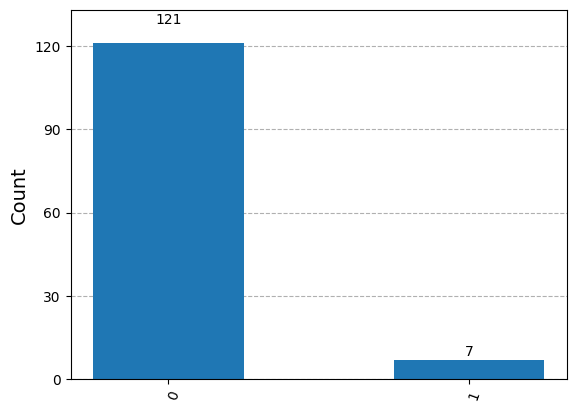

In [6]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=20, control_flow=True)
compiled = transpile(shor, backend)
job_sim = backend.run(compiled, shots=128)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
mcounts = marginal_counts(counts,indices=[8])
plot_histogram(mcounts)